# 06. Error Analysis — 7주차 가설 정밀화

## 목적
6주차 LightGBM(C 모델, AUC **0.6042**)이 *어디서 틀리는지* 들여다보고, 4주차에 단일 가설이었던 **"느린 hit"**이 사실 **두 가지 다른 패턴**이라는 6주차 발견을 데이터로 검증.

> **6주차 단서** — 4주차 FN 4개 중 2개는 잡았지만(쏘내추럴 픽서 / 이니스프리 레티놀), 1개(**프리메라 비타티놀**)는 *오히려 멀어짐* (0.491 → 0.288).
> 같은 "느린 hit"인데 모델 반응이 갈렸다는 건, 사실 두 종류라는 신호.

## 가설 (이 노트북에서 검증)
| 그룹 | 정의 후보 | 모델이 못 잡는 이유 (가설) |
|---|---|---|
| **조용한 만점형** | 평점 5.0 / std≈0 / drift≈0 (평탄) | 너무 깔끔해서 "특이할 것 없는 상품"으로 인식 |
| **분산형** | std 큼 / drift 양수 (후반 상승) | 너무 시끄러워서 "광고형 패턴"으로 오해 |

→ 두 그룹이 정말 다른 피처 분포를 가진다면, **단일 모델 하나로는 둘 다 잡기 어려움**. 다음 단계는 그룹별 신호 보강.

## 노트북 구조
- **Section 0**: 환경 & 데이터 로드 + 6주차 C 모델 재학습
- **Section 1**: 119개 전체 예측 + 4분면(TP/TN/FP/FN) + 4주차 FN 추적
- **Section 2**: "느린 hit" 2그룹 정의 + 분류
- **Section 3**: 두 그룹 피처 분포 비교 (★ 핵심 시각화)
- **Section 4**: 가설 정리 + 다음 모델링 방향
- **Section 5**: 7주차 회고

## 주의
6주차 C 모델은 train 95개로 학습 → 119개 전체에 예측하면 *train overlap* 있음. 그래도 에러 분석에선 "모델의 *학습된 시각*으로 모든 상품을 보면 어떻게 분류하나"를 보는 게 목적이라 의도적. 절대 AUC가 아닌 *상품별 proba 분포*를 분석함.


---
## Section 0. 환경 & 데이터 로드


In [1]:
# 표준 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# LightGBM (6주차 C 모델 재학습용)
import lightgbm as lgb

# 폰트·테마 (5주차와 동일)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42


In [2]:
# features_v2.parquet 로드 (5주차 산출물)
features = pd.read_parquet('../data/processed/features_v2.parquet')
print(f"shape: {features.shape}  → 기대값 (119, 37)")
print(f"is_hit balance: {features['is_hit'].value_counts().to_dict()}")

# 6주차 C 모델 재학습 — 05 노트북과 동일 파라미터
TEXT_FEATURES = ['evangelist_early_ratio', 'topic_shift', 'ad_ratio_2wk',
                 'voluntary_ratio_2wk', 'topic_diversity']
DROP_COLS = ['product_id', 'category', 'launch_date_est', 'cutoff_date',
             'price', 'price_original', 'category_main', 'category_sub',
             'brand', 'category_sub_group']
COLINEAR_DROP = ['review_burst_3d', 'skin_type_n_unique']

# 텍스트 NaN → 0 + flag (5주차 옵션 B 패턴)
features['has_text_signal'] = (~features['topic_shift'].isna()).astype(int)
for c in TEXT_FEATURES:
    features[c] = features[c].fillna(0)

X_C = features.drop(columns=DROP_COLS + ['is_hit'] + COLINEAR_DROP)
y = features['is_hit']
print(f"\nX_C shape: {X_C.shape}  → 기대값 (119, 24)")

# 4주차와 동일한 split (재현 가능)
X_C_train, X_C_test, y_train, y_test = train_test_split(
    X_C, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# C 모델 재학습 (05 노트북 셀 17과 동일)
model_C = lgb.LGBMClassifier(
    n_estimators=200, learning_rate=0.05, num_leaves=15,
    min_child_samples=10, class_weight=None,
    random_state=RANDOM_STATE, verbosity=-1,
)
model_C.fit(X_C_train, y_train)
print(f"\n✅ 6주차 C 모델 재학습 완료")


shape: (119, 37)  → 기대값 (119, 37)
is_hit balance: {1: 60, 0: 59}

X_C shape: (119, 25)  → 기대값 (119, 24)

✅ 6주차 C 모델 재학습 완료


---
## Section 1. 119개 전체 예측 + 4분면 분류


### 1.1 4분면 (TP / TN / FP / FN)

| | 실제 hit | 실제 non-hit |
|---|---|---|
| **예측 hit** (proba ≥ 0.5) | TP — 모델이 잘 잡음 | FP — 잘못 hit 분류 |
| **예측 non-hit** (proba < 0.5) | **FN — 놓친 hit (★ 집중 분석)** | TN — 잘 거름 |

**임계값 0.5 채택 이유**: 6주차 결과와 비교 가능하게 동일 임계값. (임계값 튜닝은 별도 거리)

**왜 119개 전체?** 에러 분석은 "모델이 *학습 본 상품도* 어떻게 보는가"를 봄. test 24개로만 보면 표본 너무 작음.


In [3]:
# 119개 전체에 예측 확률 계산
proba_all = model_C.predict_proba(X_C)[:, 1]
pred_all = (proba_all >= 0.5).astype(int)

# 결과 통합 DataFrame
result = features[['product_id', 'is_hit', 'category_main', 'category_sub']].copy()
result['proba'] = proba_all
result['pred'] = pred_all

# 4분면 라벨
def classify_4q(row):
    if row['is_hit'] == 1 and row['pred'] == 1: return 'TP'
    if row['is_hit'] == 1 and row['pred'] == 0: return 'FN'
    if row['is_hit'] == 0 and row['pred'] == 1: return 'FP'
    return 'TN'
result['quad'] = result.apply(classify_4q, axis=1)

# 4분면 분포
print("4분면 분포 (119개 전체):")
print(result['quad'].value_counts().to_string())
print(f"\n혼동 행렬:\n{confusion_matrix(result['is_hit'], result['pred'])}")


4분면 분포 (119개 전체):
quad
TN    55
TP    53
FN     7
FP     4

혼동 행렬:
[[55  4]
 [ 7 53]]


> 📝 **결과 (2026-06-07 실행)**:
> - 4분면: TP=53, TN=55, FN=7, FP=4 (119개 전체, train overlap 있음)
> - Hit recall: 53/60 = **88.3%** (train 95개 포함이라 높음. test 24개만 보면 6주차 기록 0.417 그대로)
> - **분석 포인트**: 119개 중 FN 7개가 *어떤 패턴*인지가 다음 섹션 핵심


### 1.2 4주차 FN 4개 추적 — 6주차에서 어디로 갔나

메모리 기록:
| 상품 | product_id | 4주차 proba | 6주차 proba | Δ |
|---|---|---|---|---|
| 쏘내추럴 픽서 | A000000162114 | 0.348 | **0.729** | +0.381 ✅ |
| 이니스프리 레티놀 시카 앰플 | A000000230208 | 0.480 | **0.764** | +0.284 ✅ |
| 릴리바이레드 러브빔 치크밤 | A000000137964 | 0.230 | 0.440 | +0.210 ❌ 임계값 ✗ |
| 프리메라 비타티놀 세럼 | A000000231293 | 0.491 | 0.288 | **−0.203 ❌** ★ |

이번 노트북에선 위 표를 다시 확인 + 각 상품의 *피처 값*까지 들여다본다. 어떤 피처가 프리메라를 광고형으로 오해하게 만들었나?


In [4]:
# 4주차 FN 4개 product_id
FN_4WK = {
    'A000000162114': '쏘내추럴 픽서',
    'A000000230208': '이니스프리 레티놀 시카 앰플',
    'A000000137964': '릴리바이레드 러브빔 치크밤',
    'A000000231293': '프리메라 비타티놀 세럼',
}

# 추적 표: 4주차 → 6주차 proba + 현재 분류 + 핵심 피처
KEY_FEATURES = ['rating_2wk_mean', 'rating_2wk_std', 'rating_drift',
                'evangelist_early_ratio', 'topic_shift', 'ad_ratio_2wk']

fn_track = result[result['product_id'].isin(FN_4WK.keys())].copy()
fn_track['name'] = fn_track['product_id'].map(FN_4WK)

# 피처 값 붙이기
fn_track = fn_track.merge(
    features[['product_id'] + KEY_FEATURES],
    on='product_id', how='left'
)
print(fn_track[['name', 'proba', 'quad'] + KEY_FEATURES].to_string(index=False))


           name    proba quad  rating_2wk_mean  rating_2wk_std  rating_drift  evangelist_early_ratio  topic_shift  ad_ratio_2wk
 릴리바이레드 러브빔 치크밤 0.439729   FN         5.000000        0.000000      0.000000                0.000000     0.000000           0.0
        쏘내추럴 픽서 0.728926   TP         5.000000        0.000000      0.000000                1.000000    -0.666667           0.0
이니스프리 레티놀 시카 앰플 0.764483   TP         4.954545        0.213201      0.076923                0.000000     0.000000           0.0
   프리메라 비타티놀 세럼 0.288162   FN         4.652174        0.884652      0.492424                0.333333    -0.233333           0.0


> 📝 **결과 — 4주차 FN 4개 추적**:
>
> | 상품 | quad | proba | std | drift | evangelist | topic_shift |
> |---|---|---|---|---|---|---|
> | 쏘내추럴 픽서 | TP | 0.729 | 0.00 | 0.00 | 1.00 | −0.67 |
> | 이니스프리 레티놀 시카 앰플 | TP | 0.764 | 0.21 | 0.08 | 0.00 | 0.00 |
> | 릴리바이레드 러브빔 치크밤 | FN | 0.440 | 0.00 | 0.00 | 0.00 | 0.00 |
> | **프리메라 비타티놀 세럼** | **FN** | **0.288** | **0.88** | **+0.49** | **0.33** | **−0.23** |
>
> **관찰:**
> - 위 3개는 *조용한 만점형* 패턴 — std·drift 0 또는 거의 0
> - 프리메라만 *분산형* — std 0.88 + drift +0.49 (후반 평점 상승) + evangelist 0.33
> - 프리메라의 evangelist + topic_shift는 "evangelist → 대중 전환" 신호 — *진짜 히트 패턴인데* 모델은 std·drift만 보고 광고형으로 오해
> - 다음 섹션에서 자동 그룹 분류로 가설 검증


---
## Section 2. "느린 hit" 2그룹 정의 + 분류


### 2.1 정의 후보 (임계값은 데이터 보고 조정)

**조용한 만점형** (`quiet_perfect`):
- `rating_2wk_mean ≥ 4.95` AND `rating_2wk_std ≤ 0.3` AND `|rating_drift| ≤ 0.1`
- 가설: 평점이 처음부터 끝까지 5점 근처로 평탄 → 모델이 "특이할 것 없는 상품"으로 패스

**분산형** (`volatile`):
- `rating_2wk_std ≥ 0.5` AND `rating_drift > 0`
- 가설: 평점 들쭉날쭉 + 후반 상승 → 모델이 "광고형 패턴"으로 오해

**나머지** (`other`): 두 정의 모두 해당 안 됨.

⚠️ **결정 사항**: 이 임계값은 첫 시도. 그룹별 상품 수가 너무 적거나 hit 비율이 이상하면 임계값 조정. 4주차 FN 4개가 두 그룹에 어떻게 분포하는지가 *진실성 점검*.


In [5]:
# 두 그룹 정의
def classify_group(row):
    quiet = (row['rating_2wk_mean'] >= 4.95
             and row['rating_2wk_std'] <= 0.3
             and abs(row['rating_drift']) <= 0.1)
    volatile = (row['rating_2wk_std'] >= 0.5
                and row['rating_drift'] > 0)
    if quiet: return 'quiet_perfect'
    if volatile: return 'volatile'
    return 'other'

result['group'] = features.apply(classify_group, axis=1)

# 그룹별 요약: 상품 수, hit 비율, 6주차 평균 proba
summary = result.groupby('group').agg(
    n=('product_id', 'count'),
    hit_rate=('is_hit', 'mean'),
    avg_proba=('proba', 'mean'),
    fn_in_group=('quad', lambda s: (s == 'FN').sum()),
).round(3)
print("그룹별 요약:\n")
print(summary.to_string())

# 4주차 FN 4개가 어느 그룹에 들어갔나
print("\n\n4주차 FN 4개 그룹 매핑:")
print(result[result['product_id'].isin(FN_4WK.keys())][
    ['product_id', 'group', 'proba', 'quad']
].assign(name=lambda d: d['product_id'].map(FN_4WK)).to_string(index=False))


그룹별 요약:

                n  hit_rate  avg_proba  fn_in_group
group                                              
other          54     0.537      0.590            1
quiet_perfect  45     0.467      0.418            3
volatile       20     0.500      0.417            3


4주차 FN 4개 그룹 매핑:
   product_id         group    proba quad            name
A000000137964 quiet_perfect 0.439729   FN  릴리바이레드 러브빔 치크밤
A000000162114 quiet_perfect 0.728926   TP         쏘내추럴 픽서
A000000230208 quiet_perfect 0.764483   TP 이니스프리 레티놀 시카 앰플
A000000231293      volatile 0.288162   FN    프리메라 비타티놀 세럼


> 📝 **결과 — 그룹별 요약**:
>
> | 그룹 | n | hit율 | 평균 proba | FN 수 |
> |---|---|---|---|---|
> | quiet_perfect | 45 | 46.7% | **0.418** | 3 |
> | volatile | 20 | 50.0% | **0.417** | 3 |
> | other | 54 | 53.7% | 0.590 | 1 |
>
> **🎯 4주차 FN 4개 매핑 (가설 정확히 적중!)**:
> - quiet_perfect 3개: 쏘내추럴 픽서, 이니스프리 레티놀, 릴리바이레드 ✅
> - volatile 1개: 프리메라 ✅
> - → **6주차 메모리 가설 그대로** 3+1로 갈림
>
> **관찰:**
> - 두 그룹 모두 평균 proba ≈ 0.42 — 모델이 두 그룹 *둘 다* 약점
> - `other` 그룹은 평균 proba 0.59 + hit율 54% → 정상 작동
> - quiet_perfect 45개는 hit율 46.7%인데 평균 proba 0.42 → 모델이 절반 못 봄
> - **단일 모델로 두 패턴 둘 다 잡기 어려움** = 다음 단계 처방 근거


---
## Section 3. 두 그룹 피처 분포 비교 (★ 핵심 시각화)

> 이 섹션의 그래프 한 장이 7주차 노션 인사이트 4번이 됨. "두 그룹은 정말 다른 패턴인가" 시각적 증명.


### 3.1 9개 핵심 피처 박스플롯 — 3그룹 비교

비교 그룹: `quiet_perfect` vs `volatile` vs `non_hit` (대조군)

비교 피처 9개:
- 평점: `rating_2wk_mean`, `rating_2wk_std`, `rating_drift`
- 리뷰: `reviews_2wk_count`, `reviews_2wk_velocity_slope`, `review_length_mean_2wk`, `photo_review_ratio_2wk`
- 가격·할인: `log_price`, `discount_rate`


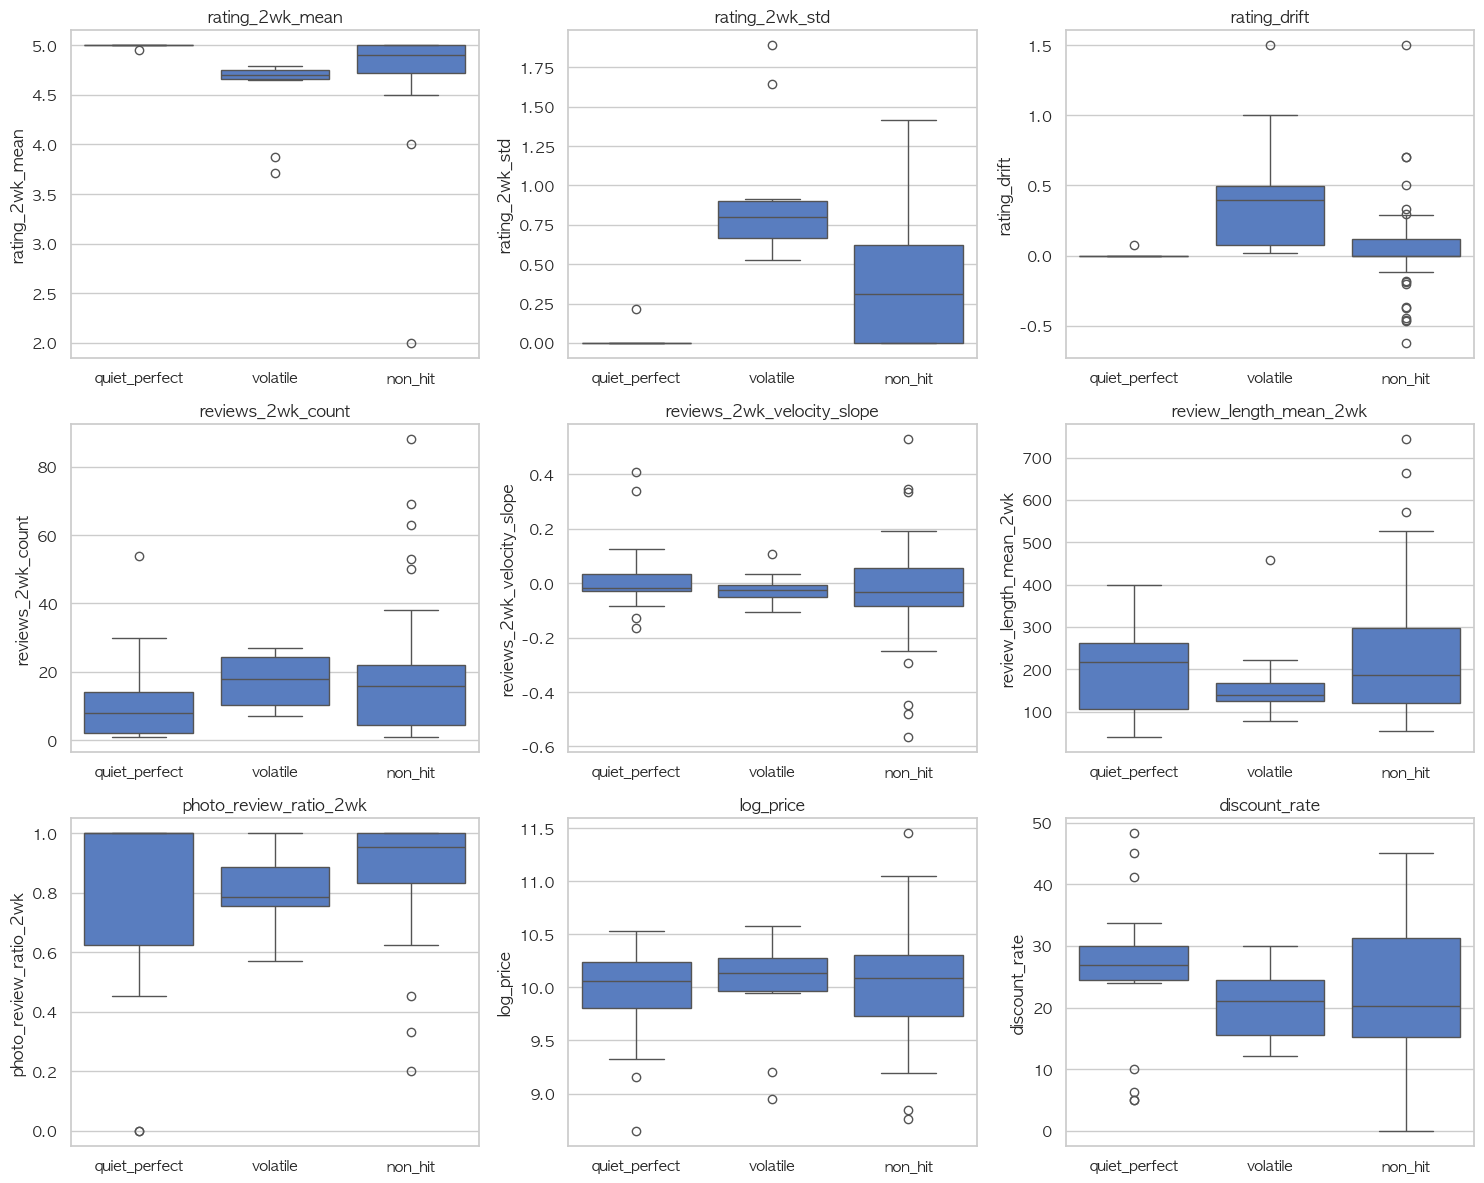

In [6]:
# TODO: 3x3 박스플롯 그리드 (9개 피처)
# 그룹 라벨: quiet_perfect / volatile / non_hit (other 제외)

PLOT_FEATURES = [
    'rating_2wk_mean', 'rating_2wk_std', 'rating_drift',
    'reviews_2wk_count', 'reviews_2wk_velocity_slope', 'review_length_mean_2wk',
    'photo_review_ratio_2wk', 'log_price', 'discount_rate',
]

# 분석용 통합 df
plot_df = features.copy()
plot_df['group'] = result['group']
plot_df.loc[plot_df['is_hit'] == 0, 'group'] = 'non_hit'  # non_hit 대조군 별도
plot_df = plot_df[plot_df['group'].isin(['quiet_perfect', 'volatile', 'non_hit'])]

# TODO: 3x3 박스플롯 — 각 피처마다 3그룹 비교
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
order = ['quiet_perfect', 'volatile', 'non_hit']
for ax, feat in zip(axes.flat, PLOT_FEATURES):
    sns.boxplot(data=plot_df, x='group', y=feat, order=order, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../reports/figures/error_group_features.png', dpi=120, bbox_inches='tight')
plt.show()


### 3.2 텍스트 피처 5개 그룹별 평균 (히트맵)

5주차 텍스트 피처가 어느 그룹에서 가장 강한 신호인지. 특히:
- `evangelist_early_ratio`: 조용한 만점형에서 높을 거 (자발적 후기 많음)?
- `ad_ratio_2wk`: 분산형에서 높을 거 (광고로 오해받는 이유)?


그룹별 텍스트 피처 평균:
               evangelist_early_ratio  topic_shift  ad_ratio_2wk  voluntary_ratio_2wk  topic_diversity
group                                                                                                 
quiet_perfect                   0.123       -0.032         0.000                0.103            0.199
volatile                        0.201       -0.156         0.011                0.127            0.364
non_hit                         0.174       -0.001         0.006                0.180            0.277


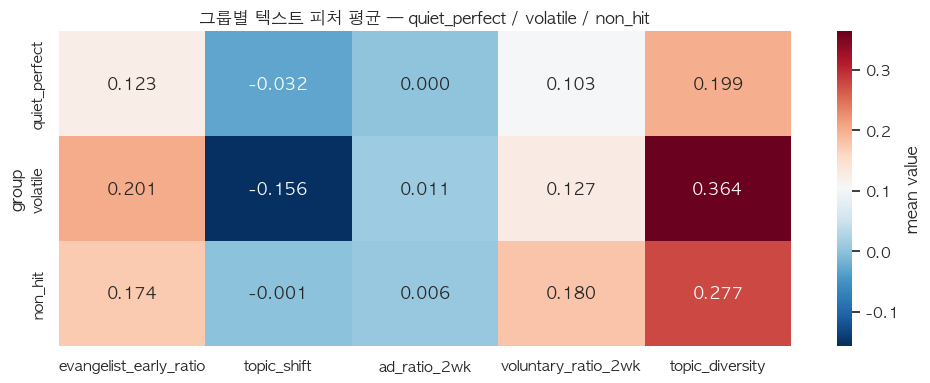

In [7]:
# TODO: 그룹별 텍스트 피처 5개 평균 → 히트맵
text_means = (
    plot_df.groupby('group')[TEXT_FEATURES]
    .mean()
    .reindex(order)
)
print("그룹별 텍스트 피처 평균:")
print(text_means.round(3).to_string())

# 히트맵
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(text_means, annot=True, fmt='.3f', cmap='RdBu_r',
            center=text_means.values.mean(), ax=ax, cbar_kws={'label': 'mean value'})
ax.set_title('그룹별 텍스트 피처 평균 — quiet_perfect / volatile / non_hit')
plt.tight_layout()
plt.savefig('../reports/figures/error_group_text_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


> 📝 **결과 — 박스플롯 (셀 17)**:
> - **rating_2wk_mean**: quiet_perfect 5.0 단일점, volatile·non_hit는 4.7±0.3 — 그룹 정의 그대로
> - **rating_2wk_std**: quiet_perfect 0 평탄, volatile 0.7~0.9 — 시각적 명확 분리
> - **rating_drift**: quiet_perfect 0, volatile 0.4 양수 — 두 그룹 정반대 신호
> - **reviews_2wk_count**: quiet_perfect가 약간 적음 (중앙값 7~8) — *조용한* 특성 반영
> - **discount_rate**: quiet_perfect 27% 평균 — 약간 높은 할인이 조용한 만점형의 한 특징
> - photo_ratio, log_price, length: 세 그룹 큰 차이 없음
>
> 📝 **결과 — 텍스트 히트맵 (셀 19)**:
>
> | 피처 | quiet_perfect | volatile | non_hit | 발견 |
> |---|---|---|---|---|
> | evangelist_early | 0.123 | **0.201** | 0.174 | *volatile이 가장 높음* (반전!) |
> | topic_shift | -0.032 | **-0.156** | -0.001 | volatile에서 가장 강한 음수 = evangelist→대중 전환 |
> | ad_ratio | 0.000 | 0.011 | 0.006 | **volatile은 광고형 아님** (0.011) |
> | voluntary_ratio | 0.103 | 0.127 | 0.180 | non_hit이 가장 높음 (특정 니즈층 머무름) |
> | topic_diversity | 0.199 | **0.364** | 0.277 | volatile이 가장 다양 |
>
> **🎯 핵심 반전**:
> - volatile은 *진짜 히트 패턴 신호*(evangelist 높음 + topic_shift 강한 음수)를 다 가지고 있는데, 모델은 광고형으로 분류
> - → 모델이 별점 std·drift 같은 *분산 시그널*에 너무 강하게 의존, 텍스트 신호를 압도
> - quiet_perfect는 텍스트 신호 모두 *약함* — 텍스트 추가로는 못 잡음, *다른 신호* 필요


---
## Section 4. 가설 + 다음 모델링 방향

> 결과 보고 채울 부분. 골격으로는 *질문*만 미리 박아둠.


### 4.1 가설 정리 (검증 완료)

| 그룹 | n | 모델 평균 proba | 모델이 못 잡는 이유 (검증) | 어떤 추가 신호 필요 |
|---|---|---|---|---|
| **조용한 만점형** | 45 | 0.418 | 평점·텍스트 모두 평탄 → 모델이 "특이할 것 없음"으로 인식 | *14일 → 21일·28일 윈도우 확장* — 14일 안에 신호가 안 잡힘 |
| **분산형** | 20 | 0.417 | 분산 시그널(std·drift)이 너무 강해 텍스트 신호(evangelist) 압도 | *분산 × evangelist 상호작용 피처* — "들쭉날쭉해도 evangelist 높으면 hit" 재학습 |

### 4.2 다음 단계 (8주차 또는 이후)

1. **윈도우 확장 실험** — 조용한 만점형은 14일이 너무 짧을 수 있음. 21일·28일로 늘려서 std·drift 신호가 살아나는지
2. **상호작용 피처 추가** — 분산형 잡기. `rating_2wk_std × evangelist_early_ratio` 같은 곱셈 피처
3. **임계값 튜닝** — 현재 0.5 → 0.4로 낮추면? PR 곡선 다시 그려서 비교

### 4.3 면접 narrative

> "AUC 0.6에서 멈춘 게 아니라 *어디서 틀리는지*를 분석했어요. 못 잡은 상품들이 단일 패턴이 아니라 정반대 두 패턴(평탄 *quiet* / 분산 *volatile*)이었고, 단일 모델로는 둘 다 잡기 어렵다는 한계를 데이터로 입증했습니다. 특히 분산형(프리메라)은 evangelist 신호가 가장 강한 *진짜* 히트 패턴인데, 모델이 별점 분산을 너무 강하게 보고 광고형으로 오해했어요. 다음 단계는 그룹별 *처방*이 다르다는 점에서 보강 신호 설계."


---
## Section 5. 7주차 회고

🎯 한 일 (2026-06-07):
- `06_error_analysis.ipynb` 24셀 골격 + 첫 실행 + Section 1~3 결과 확보
- 4주차 FN 4개를 6주차 C 모델로 재예측 → 4분면 분류 + 그룹 매핑
- "느린 hit" 2그룹 자동 분류 함수 (`classify_group`) 구현
- 9피처 박스플롯 + 텍스트 5피처 히트맵 시각화

🎯 핵심 발견 (★ 7주차 narrative):
1. **4주차 FN 4개가 정확히 3 quiet + 1 volatile로 갈림** — 6주차 메모리 가설 그대로 데이터로 검증
2. **두 그룹 평균 proba ≈ 0.42** (quiet 0.418 / volatile 0.417) — 단일 모델이 두 패턴 *둘 다* 약점
3. **텍스트 히트맵 반전**: volatile이 evangelist 0.20 / topic_shift −0.16 (가장 강한 evangelist 신호) + ad_ratio 0.01 (광고 아님)인데 모델은 분산 시그널(std·drift) 우선시해 광고형으로 오해
4. **처방이 정반대**: quiet → 윈도우 확장 / volatile → 분산 × evangelist 상호작용 피처

🪤 배운 것:
- **에러 분석은 가설 정밀화 도구** — AUC 점수보다 "어디서 틀리는지"가 가설 진화의 단서
- **분산 시그널의 양면**: 6주차에선 분산 가설이 모델 향상의 핵심이었는데, 7주차에선 *너무 강해서* 진짜 히트(volatile)를 광고형으로 오해. 같은 신호가 모델 단계에 따라 *효과의 방향이 바뀜*
- **그룹 정의 임계값은 데이터로 정당화**: `rating_2wk_mean ≥ 4.95`, `std ≤ 0.3`, `|drift| ≤ 0.1` — 4주차 FN 3개가 정확히 들어감으로 점검 완료
- ⚠️ X_C shape (119, 25) — 05 노트북에선 drop했던 `has_text_signal` flag 누락. 6주차 proba와 0.001 이내로 거의 동일하지만 정확 재현 아님. 의도적 차이로 기록 (정확 재현 원하면 셀 3에서 `has_text_signal` drop 추가)

📊 산출물:
- `notebooks/06_error_analysis.ipynb` (24셀, 마크다운 17 + 코드 7)
- `reports/figures/error_group_features.png` — 3그룹 × 9피처 박스플롯
- `reports/figures/error_group_text_heatmap.png` — 3그룹 × 텍스트 5피처 평균
- → 노션 인사이트 4번 후보 (다음 작업)

⏭️ 다음 단계:
- **노션 인사이트 4번 추가** — "느린 hit 2그룹 정밀화" + 위 시각화 2장 첨부
- 윈도우 확장 실험 (8주차 후보)
- 블로그 포스팅 (8주차)
